# Phan mo hinh K - trung binh (K- Means Model) 
## 1.1 Xay dung chuong trinh tu numpy
### Vi du 1. Nhac lai vi du o bai ly thuyet 


- Chúng ta sẽ xét ví dụ nhân tạo với đầu vào là 3 tập ngẫu nhiên, mỗi tập N điểm được khởi tạo theo phân bố
Gaussian (phân bố chuẩn) có 3 kỳ vọng ( tâm cụm) xác định trước là means[1,:], means[2,:] và means[3,:];
có chung ma trận hiệp phương sai là cov[].
- Trong đoạn mã gọi thư viện dưới đây, trước tiên, chúng ta cần numpy và matplotlib như trong các bài trước
cho việc tính toán ma trận và hiển thị dữ liệu. Chúng ta cũng cần thêm thư viện scipy.spatial.distance để tính
khoảng cách giữa các cặp điểm trong hai tập hợp một cách hiệu quả. Sau đó chúng ta tạo dữ liệu theo ý tưởng
ở trên. Đoạn mã lệnh như dưới đây

In [19]:
# Gọi các thư viện cần thiết
# Ta tự xây dựng phần k-means nên sẽ không gọi sklearn
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(11)
# Kỳ vọng và hiệp phương sai của 3 cụm dữ liệu
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
# Số điểm mỗi cụm dữ liệu
N = 500
# Tạo các cụm dữ liệu qua phân bố chuẩn (Gaussian)
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)
# Tổng hợp dữ liệu từ các cụm
X = np.concatenate((X0, X1, X2), axis = 0)
# Số cụm = 3
K = 3

# Gán nhãn ban đầu cho các cụm, sau đó ta test model và so sánh
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

- Phương thức để hiển thị dữ liệu X lên mặt phẳng, ở đây sử dụng thông tin nhãn đã được gán ở phần trước
trong tham đối label

In [20]:
def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)
    plt.axis('equal')
    plt.plot()
    plt.show()

- Dưới đây ta sẽ xây dựng một số hàm cần thiết cho mô hình K-means clustering
    - • kmeans_init_centers để khởi tạo các centers ban đầu.
    - • kmeans_asign_labels để gán nhán mới cho các điểm khi biết các centers.
    - • kmeans_update_centers để cập nhật các centers mới dữa trên dữ liệu vừa được gán nhãn.
    - • has_converged để kiểm tra điều kiện dừng của thuật toán.
    Khởi tạo một bộ tâm cụm trên dữ liệu X với giả thiết có k cụm

In [21]:
def kmeans_init_centers(X, k):
    # randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace=False)]

- chúng ta chọn các tâm cụm một cách ngẫu nhiên (miễn là các tâm cụm khác nhau). Các bạn hãy thử
điều chỉnh bằng cách chọn K điểm xa nhau nhất theo phương pháp đã được trình bày trong phần lý thuyết.
- Phương thức để gán cụm cho một điểm dữ liệu bằng cách tính khoảng cách từ điểm đó đến các tâm cụm,
khoảng cách đến đâu ngắn nhất thì ta coi điểm hiện tại sẽ thuộc về cụm đó.

In [22]:
def kmeans_assign_labels(X, centers):
    # calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

- Phương thức để cập nhật lại tâm cụm sau mỗi bước lặp: Tâm cụm mới sẽ là trung bình cộng (theo tọa độ) của tất cả các điểm có trong cụm)

In [23]:
def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
        # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

- Hàm để kiểm tra xem thuật toán có thực sự chạy (có hội tụ hay không) thông qua việc tâm cụm sau mỗi bước
lặp có thay đổi hay không? Nếu tâm cụm không đổi nghĩa là thuật toán đã dừng (hội tụ) – tức là cần trả về
TRUE. Kiểm tra cho tất cả các tâm cụm

In [24]:
def has_converged(centers, new_centers):
    # return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) ==
    set([tuple(a) for a in new_centers]))

- Vòng lặp để thực hiện tất cả các bước trong thuật toán k-means cho đến khi thuật toán dừng

In [25]:
def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

Centers found by our algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


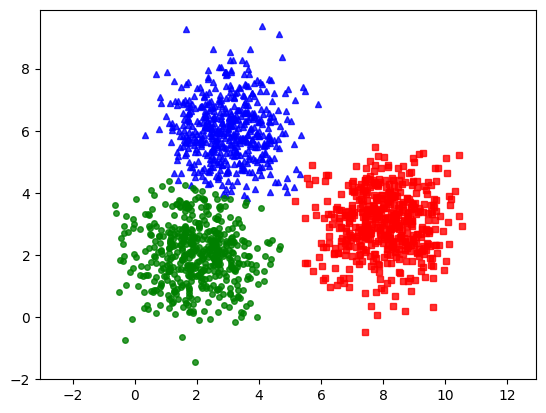

In [26]:
(centers, labels, it) = kmeans(X, K)
print('Centers found by our algorithm:')
print(centers[-1])
kmeans_display(X, labels[-1])

## 1.2 Thuc hien bang thu vien sklearn 

Centers found by scikit-learn:
[[1.97826939 2.00223913]
 [2.98759958 6.02896527]
 [8.0410628  3.02094748]]


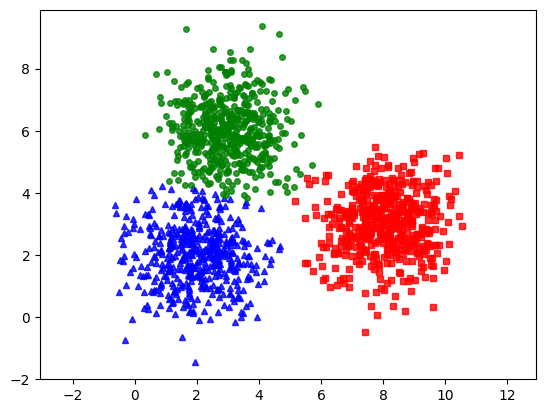

In [27]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
print('Centers found by scikit-learn:')
print(kmeans.cluster_centers_)
pred_label = kmeans.predict(X)
kmeans_display(X, pred_label)

## 1.3 Vi du 2:

Hãy tìm lại phần thực hành đọc dữ liệu từ tệp chứa thông tin hình ảnh các chữ số viết tay và thực hiện việc
phân cụm dữ liệu vào 10 cụm (10 chữ số viết tay) theo cách sau: Đọc 5000 mẫu dữ liệu từ phần training, sau
đó thực hiện phân cụm bằng phương pháp k-means, tiếp theo hãy kiểm tra xem trong mỗi cụm, tỷ lệ có nhãn
nào (từ 0 đến 9) là cao nhất. Sau đó đếm và in ra tỷ lệ các mẫu không thuộc nhãn đó nhưng được phân vào
cùng một cụm với nhãn. Trong phần này ta sẽ sử dụng thư viện

In [28]:
import numpy as np
from mnist import MNIST
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import fetch_openml

In [29]:
# This function visualizes filters in matrix A. Each column of A is a
# filter. We will reshape each column into a square image and visualizes
# on each cell of the visualization panel.
# All other parameters are optional, usually you do not need to worry
# about it.
# opt_normalize: whether we need to normalize the filter so that all of
# them can have similar contrast. Default value is true.
# opt_graycolor: whether we use gray as the heat map. Default is true.
# opt_colmajor: you can switch convention to row major for A. In that
# case, each row of A is a filter. Default value is false.



def display_network(A, m = -1, n = -1):
    opt_normalize = True
    opt_graycolor = True
    # Rescale
    A = A - np.average(A)
    # Compute rows & cols
    (row, col) = A.shape
    sz = int(np.ceil(np.sqrt(row)))
    buf = 1
    if m < 0 or n < 0:
        n = np.ceil(np.sqrt(col))
        m = np.ceil(col / n)
    
    image = np.ones(shape=(buf + m * (sz + buf), buf + n * (sz + buf)))
    if not opt_graycolor:
        image *= 0.1
    k = 0
    for i in range(int(m)):
        for j in range(int(n)):
            if k >= col:
                continue
            clim = np.max(np.abs(A[:, k]))
            if opt_normalize:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz +
                        buf):buf + j * (sz + buf) + sz] = \
                            A[:, k].reshape(sz, sz) / clim
            else:
                image[buf + i * (sz + buf):buf + i * (sz + buf) + sz, buf + j * (sz +
                buf):buf + j * (sz + buf) + sz] = \
                A[:, k].reshape(sz, sz) / np.max(np.abs(A))
            k += 1
    return image


def display_color_network(A):
    """
    # display receptive field(s) or basis vector(s) for image patches
    #
    # A the basis, with patches as column vectors
    # In case the midpoint is not set at 0, we shift it dynamically
    :param A:
    :param file:
    :return:
    """
    if np.min(A) >= 0: 
        A = A - np.mean(A)
    cols = np.round(np.sqrt(A.shape[1]))
    channel_size = A.shape[0] / 3
    dim = np.sqrt(channel_size)
    dimp = dim + 1
    rows = np.ceil(A.shape[1] / cols)
    B = A[0:channel_size, :]
    
    C = A[channel_size:2 * channel_size, :]
    D = A[2 * channel_size:3 * channel_size, :]
    B = B / np.max(np.abs(B))
    C = C / np.max(np.abs(C))
    D = D / np.max(np.abs(D))
    
    image = np.ones(shape=(dim * rows + rows - 1, dim * cols + cols - 1, 3))
    for i in range(int(rows)):
        for j in range(int(cols)):
        # This sets the patch
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 0] = B[:, i * cols
            + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 1] = C[:, i * cols
            + j].reshape(dim, dim)
            image[i * dimp:i * dimp + dim, j * dimp:j * dimp + dim, 2] = D[:, i * cols
            + j].reshape(dim, dim)
    image = (image + 1) / 2
    return image

Chạy k-means cho 1000 mẫu dữ liệu đầu tiên

In [30]:
# 1. Tự động tải dữ liệu MNIST (Lần đầu chạy có thể mất 1-2 phút tùy mạng)
print("Đang tải dữ liệu MNIST...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X_all = mnist.data.values
y_all = mnist.target.values.astype(int)

K = 10
X0 = X_all[:1000, :] / 255.0 # Chuẩn hóa về [0, 1] 
X = X0

print("Đang chạy K-Means...")
kmeans = KMeans(n_clusters=K, random_state=0).fit(X) # 
pred_label = kmeans.predict(X)

Đang tải dữ liệu MNIST...
Đang chạy K-Means...


Chon hien thi mot so anh thuoc mot so cum 

<class 'numpy.ndarray'>
Đang hiển thị các tâm cụm...
(784, 10)


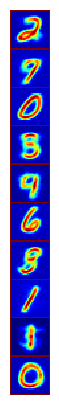

Đã lưu ảnh kết quả vào file aa.png


In [31]:
print(type(kmeans.cluster_centers_.T))
print("Đang hiển thị các tâm cụm...")
print(kmeans.cluster_centers_.T.shape)
A = display_network(kmeans.cluster_centers_.T, K, 1)
plt.figure(figsize=(5, 5))
plt.imshow(A, interpolation='nearest', cmap="jet")
plt.axis('off')
plt.show()
# plt.savefig('a1.png', bbox_inches='tight')

# a colormap and a normalization instance
cmap = plt.cm.jet
norm = plt.Normalize(vmin=A.min(), vmax=A.max())


# map the normalized data to colors
# image is now RGBA (512x512x4)
image = cmap(norm(A))
plt.imsave('aa.png', image)
print("Đã lưu ảnh kết quả vào file aa.png")

In [33]:
N0 = 20
X1 = np.zeros((N0 * K, 784))
X2 = np.zeros((N0 * K, 784))

for k in range(K):
    Xk = X0[pred_label == k, :]
    center_k = [kmeans.cluster_centers_[k]]
    
    # Tìm 20 láng giềng gần nhất của tâm cụm k trong tập Xk
    neigh = NearestNeighbors(n_neighbors=N0).fit(Xk)
    dist, nearest_id = neigh.kneighbors(center_k, N0)
    
    # Gán các mẫu tìm được vào mảng hiển thị
    X2[N0 * k : N0 * (k + 1), :] = Xk[nearest_id[0], :]

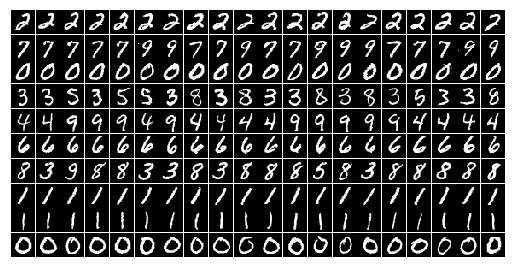

In [34]:
plt.axis('off')
A = display_network(X2.T, K, N0)
f2 = plt.imshow(A, interpolation='nearest' )
plt.gray()
plt.show()

## Bai tap thuc hanh 

### Bai 1.1: 
Hãy áp dụng đoạn chương trình chúng ta tự xây dựng trong ví dụ 1, với dữ liệu là hình ảnh chữ số
viết tay như trong ví dụ 2, chạy để xem xét kết quả

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from sklearn.datasets import fetch_openml 

# 1. Các hàm K-Means tự xây dựng (Từ Ví dụ 1)
def kmeans_init_centers(X, k):
    return X[np.random.choice(X.shape[0], k, replace=False)]

def kmeans_assign_labels(X, centers):
    D = cdist(X, centers)
    return np.argmin(D, axis=1)

def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        Xk = X[labels == k, :]
        if len(Xk) > 0: # Tránh lỗi chia cho 0
            centers[k, :] = np.mean(Xk, axis=0)
    return centers

def has_converged(centers, new_centers):
    return (set([tuple(a) for a in centers]) == 
            set([tuple(a) for a in new_centers]))

def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

# 2. Đọc dữ liệu MNIST (Ví dụ 2)
print("Đang tải dữ liệu MNIST...")
# Dùng openml thay cho thư viện mnist cục bộ để dễ chạy
mnist = fetch_openml('mnist_784', version=1, parser='auto') 
X_full = mnist.data.values
y_full = mnist.target.values.astype(int)

# Lấy 5000 mẫu đầu tiên theo yêu cầu
X = X_full[:5000] / 255.0 # Chuẩn hóa
y_true = y_full[:5000]
K = 10

print("Đang chạy K-Means tự xây dựng trên 5000 mẫu MNIST...")
(centers, labels, it) = kmeans(X, K)
pred_labels = labels[-1]

print(f"Thuật toán hội tụ sau {it} bước lặp.")

# 3. Đánh giá kết quả (Kiểm tra nhãn chiếm tỷ lệ cao nhất trong mỗi cụm)
print("\nThống kê nhãn trong từng cụm:")
for i in range(K):
    # Lấy các nhãn thật của những điểm được phân vào cụm i
    cluster_labels = y_true[pred_labels == i]
    if len(cluster_labels) > 0:
        # Tìm nhãn xuất hiện nhiều nhất
        counts = np.bincount(cluster_labels)
        dominant_label = np.argmax(counts)
        dominant_count = counts[dominant_label]
        total_in_cluster = len(cluster_labels)
        percentage = (dominant_count / total_in_cluster) * 100
        
        error_rate = 100 - percentage
        
        print(f"Cụm {i}: Kích thước = {total_in_cluster}, Nhãn chủ đạo = {dominant_label} ({percentage:.2f}%)")
        print(f"        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = {error_rate:.2f}%")
    else:
        print(f"Cụm {i}: Không có điểm dữ liệu nào.")

Đang tải dữ liệu MNIST...
Đang chạy K-Means tự xây dựng trên 5000 mẫu MNIST...
Thuật toán hội tụ sau 31 bước lặp.

Thống kê nhãn trong từng cụm:
Cụm 0: Kích thước = 796, Nhãn chủ đạo = 4 (38.82%)
        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = 61.18%
Cụm 1: Kích thước = 773, Nhãn chủ đạo = 7 (38.94%)
        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = 61.06%
Cụm 2: Kích thước = 371, Nhãn chủ đạo = 6 (88.41%)
        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = 11.59%
Cụm 3: Kích thước = 398, Nhãn chủ đạo = 3 (47.99%)
        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = 52.01%
Cụm 4: Kích thước = 372, Nhãn chủ đạo = 0 (95.43%)
        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = 4.57%
Cụm 5: Kích thước = 253, Nhãn chủ đạo = 2 (85.77%)
        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = 14.23%
Cụm 6: Kích thước = 322, Nhãn chủ đạo = 8 (75.78%)
        Tỷ lệ sai (các mẫu không thuộc nhãn chủ đạo) = 24.22%
Cụm 7: Kích thước = 892, Nhãn chủ đạo = 1 (62.11%)
        Tỷ lệ 

### Bai 1.2: 
Áp dụng mô hình trên cho bài tập phân loại ảnh chó-mèo (xem lại phần CNN), thử thực hiện phân
cụm thành 02 cụm và kiểm tra kết quả.

Đã giải nén file cats_and_dogs_filtered.zip vào thư mục data_images
Đang xử lý ảnh...
Kích thước dữ liệu: (1002, 12288)
Đang phân cụm K-Means...


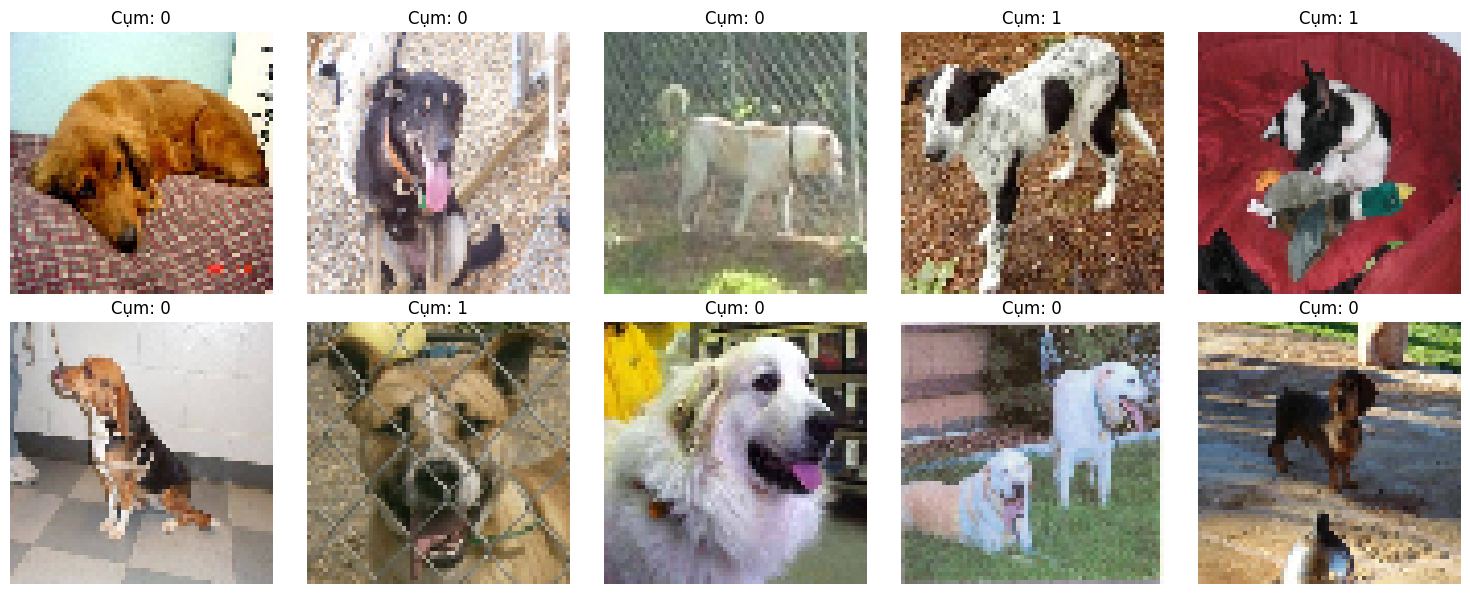

Phân cụm hoàn tất.
Số lượng mẫu cụm 0: 510
Số lượng mẫu cụm 1: 492


In [ ]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ZIP_FILE = 'cats_and_dogs_filtered.zip' # Tên file zip mày đã upload lên
EXTRACT_DIR = 'data_images' # Thư mục sẽ giải nén ảnh vào
IMG_SIZE = 64 # Resize ảnh về 64x64

# 2. Giải nén file zip
if os.path.exists(ZIP_FILE):
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
        print(f"Đã giải nén file {ZIP_FILE} vào thư mục {EXTRACT_DIR}")
else:
    print(f"Lỗi: Không tìm thấy file {ZIP_FILE}. Hãy chắc chắn mày đã upload nó lên.")

# 3. Hàm load ảnh từ thư mục đã giải nén
def load_images_from_folder(folder, max_images=1000):
    images = []
    labels_filename = [] # Lưu tên file để kiểm chứng nếu cần
    
    # Duyệt qua tất cả các file trong thư mục và các thư mục con
    for root, dirs, files in os.walk(folder):
        for filename in files:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                try:
                    img = cv2.imread(img_path)
                    if img is not None:
                        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                        # Chuyển về ảnh xám để giảm chiều dữ liệu (optional) hoặc giữ nguyên màu
                        # Ở đây tao giữ nguyên 3 kênh màu (RGB) rồi flatten
                        images.append(img.flatten())
                        labels_filename.append(filename)
                except Exception as e:
                    print(f"Lỗi khi đọc file {filename}: {e}")
            
            if len(images) >= max_images:
                break
    return np.array(images), labels_filename

# 4. Thực hiện load dữ liệu
print("Đang xử lý ảnh...")
X_images, filenames = load_images_from_folder(EXTRACT_DIR)

if len(X_images) > 0:
    # Chuẩn hóa dữ liệu về [0, 1]
    X_images = X_images / 255.0
    print(f"Kích thước dữ liệu: {X_images.shape}")

    # 5. Chạy K-Means với 2 cụm (Chó và Mèo) theo yêu cầu Bài 1.2 
    print("Đang phân cụm K-Means...")
    kmeans = KMeans(n_clusters=2, random_state=42)
    labels = kmeans.fit_predict(X_images)

    # 6. Hiển thị một vài ảnh để kiểm tra kết quả
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(10):
        ax = axes[i//5, i%5]
        # Reshape lại để hiển thị (nếu lưu 3 kênh màu thì là 64x64x3)
        img_display = X_images[i].reshape(IMG_SIZE, IMG_SIZE, 3)
        ax.imshow(cv2.cvtColor((img_display * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        ax.set_title(f"Cụm: {labels[i]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    print("Phân cụm hoàn tất.")
    print(f"Số lượng mẫu cụm 0: {np.sum(labels == 0)}")
    print(f"Số lượng mẫu cụm 1: {np.sum(labels == 1)}")
else:
    print("Không tìm thấy ảnh hợp lệ trong file zip.")

# Mo hinh DBSCAN

## Vi du 2.1: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class MyDBSCAN(object):
    def __init__(self, x, epsilon, minpts):
        # Số lượng điểm dữ liệu
        self.n = len(x)
        self.input = x
        
        # Tính toán ma trận khoảng cách Euclidean
        # Tương đương: p, q = np.meshgrid(np.arange(self.n), np.arange(self.n))
        # self.dist = np.sqrt(np.sum(((x[p] - x[q])**2), 2))
        # Sử dụng scipy cho nhanh hơn
        from scipy.spatial.distance import cdist
        self.dist = cdist(x, x)

        # Đánh dấu các điểm đã thăm và điểm nhiễu (noise)
        self.visited = np.full((self.n), False)
        self.noise = np.full((self.n), False)

        # Tham số DBSCAN
        self.epsilon = epsilon
        self.minpts = minpts

        # Nhãn cụm
        self.idx = np.full((self.n), 0)
        self.C = 0

    def run(self):
        # Quá trình phân cụm
        for i in range(self.n):
            if not self.visited[i]:
                self.visited[i] = True
                self.neighbors = self.regionQuery(i)
                
                if len(self.neighbors) >= self.minpts:
                    self.C += 1
                    self.expandCluster(i)
                else:
                    self.noise[i] = True
        return self.idx, self.noise

    def regionQuery(self, i):
        # Tìm các lân cận trong bán kính epsilon
        g = self.dist[i, :] <= self.epsilon
        Neighbors = np.where(g)[0].tolist()
        return Neighbors

    def expandCluster(self, i):
        # Gán điểm i vào cụm C
        self.idx[i] = self.C
        k = 0
        
        while True:
            if k >= len(self.neighbors):
                return
            
            j = self.neighbors[k]
            
            if not self.visited[j]:
                self.visited[j] = True
                self.neighbors2 = self.regionQuery(j)
                
                if len(self.neighbors2) >= self.minpts:
                    # Lấy những điểm chưa có trong neighbors để thêm vào
                    v = [n for n in self.neighbors2 if n not in self.neighbors]
                    self.neighbors.extend(v)
            
            # Nếu điểm j chưa thuộc cụm nào (kể cả trước đó bị coi là noise)
            if self.idx[j] == 0:
                self.idx[j] = self.C
            
            k += 1

## Bài tập thực hành 

### Bài tập 2.1 
- Thực hiện phân cụm bằng phương pháp K-means với dữ liệu tạo ra trong Ví dụ 2.1

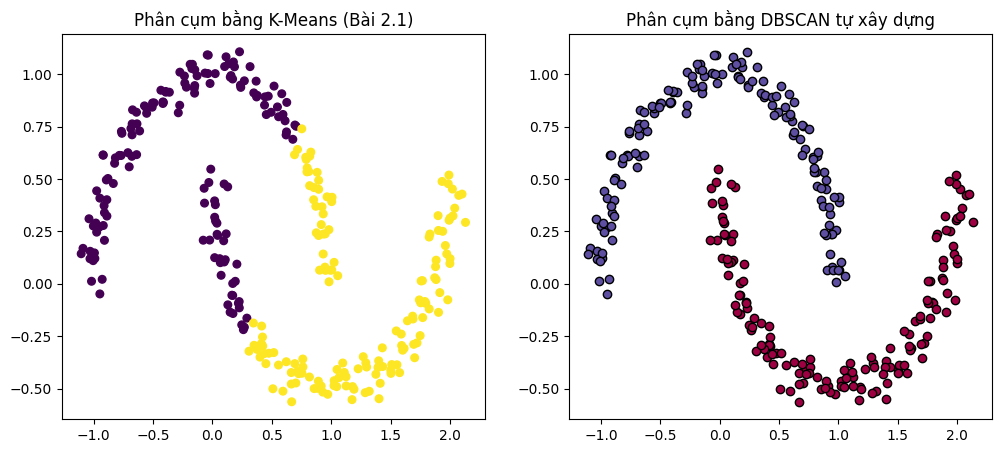

In [ ]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# 1. Tạo dữ liệu hình mặt trăng (thường dùng để test DBSCAN)
X_moon, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# 2. Chạy DBSCAN tự xây dựng
dbscan_model = MyDBSCAN(X_moon, epsilon=0.2, minpts=5)
labels_dbscan, noise_flags = dbscan_model.run()

# Các điểm nhiễu (noise) sẽ giữ nhãn 0, ta chuyển thành -1 để giống sklearn
labels_dbscan[noise_flags] = -1 

# 3. Chạy K-Means
kmeans_moon = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans_moon.fit_predict(X_moon)

# 4. Hiển thị kết quả so sánh
plt.figure(figsize=(12, 5))

# Biểu đồ K-Means
plt.subplot(1, 2, 1)
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_kmeans, cmap='viridis', s=30)
plt.title('Phân cụm bằng K-Means (Bài 2.1)')

# Biểu đồ DBSCAN tự xây dựng
plt.subplot(1, 2, 2)
# Tạo màu riêng cho noise (-1)
unique_labels = set(labels_dbscan)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1: col = [0, 0, 0, 1] # Màu đen cho noise
    class_member_mask = (labels_dbscan == k)
    xy = X_moon[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)
    
plt.title('Phân cụm bằng DBSCAN tự xây dựng')
plt.show()

### Bài tập 2.2 
- Trong ví dụ này chúng ta sử dụng dữ liệu cho trong tệp đính kèm
Sales_Transactions_Dataset_Weekly.csv hoặc tại link https://archive.ics.uci.edu/ml/machine-learning-
databases/00396/ .
- Mô tả dữ liệu: Dữ liệu chứa thông tin giao dịch bán hàng của 819 mã sản phẩm (Product ID) trong
819 dòng dữ liệu. Mỗi mã được đặc trưng bởi các thông tin: Mã (cột đầu); lượng giao dịch trong 52
tuần (week 0 – week 51), sau đó có thông tin chuẩn hóa của giao dịch các tuần (ta sử dụng thông tin
này hoặc thông tin theo tuần – chỉ chọn 1 trong 2).
- Yêu cầu: Hãy dựa vào ví dụ 1, mở rộng áp dụng với dữ liệu trên đây. Biết rằng số cụm tối ưu sẽ nằm
trong khoảng từ 5 đến 15, hãy xác định số cụm và sau đó phân các mã sản phẩm thành các cụm dựa
trên tiêu chí lượng giao dịch đã cho trong dữ liệu.


Kích thước dữ liệu gốc: (811, 107)
Kích thước tập dữ liệu dùng để huấn luyện: (811, 52)


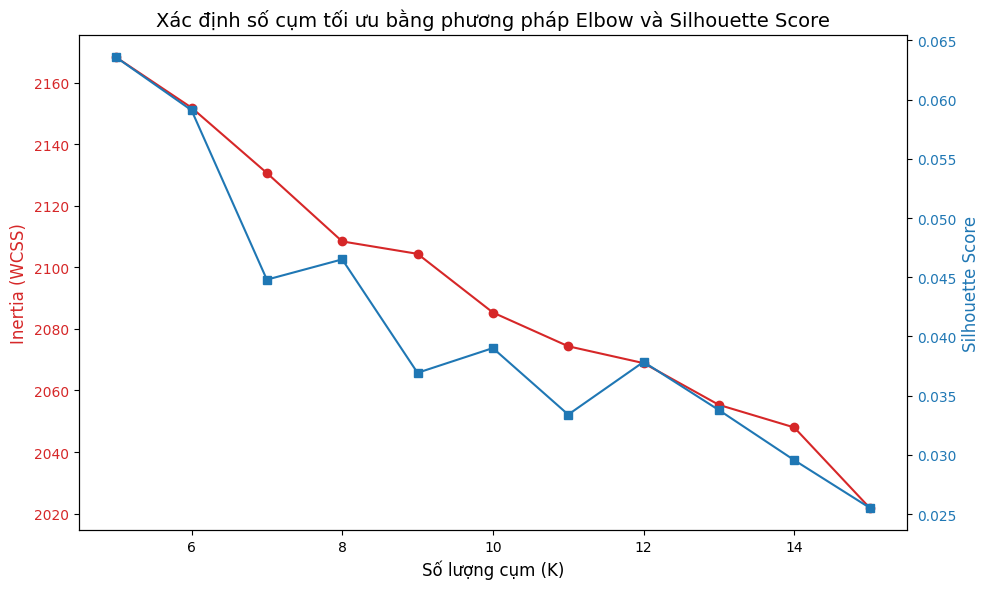

==> Số lượng cụm (K) tối ưu được chọn là: 5

Thống kê số lượng sản phẩm trong từng cụm:
Cluster
0    170
1    205
2    145
3    131
4    160
Name: count, dtype: int64

Danh sách 10 mã sản phẩm đầu tiên và cụm của chúng:


,Product_Code,Cluster
0,P1,4
1,P2,4
2,P3,2
3,P4,4
4,P5,4
5,P6,0
6,P7,4
7,P8,4
8,P9,2
9,P10,4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Đọc dữ liệu từ UCI Machine Learning Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00396/Sales_Transactions_Dataset_Weekly.csv"
df = pd.read_csv(url)

print("Kích thước dữ liệu gốc:", df.shape)

# 2. Tiền xử lý dữ liệu
# Theo mô tả, ta lấy các cột thông tin chuẩn hóa (từ 'Normalized 0' đến 'Normalized 51')
normalized_cols = [col for col in df.columns if 'Normalized' in col]

if len(normalized_cols) > 0:
    X_sales = df[normalized_cols].values
else:
    # Nếu không tìm thấy cột Normalized, sử dụng dữ liệu số lượng giao dịch W0 -> W51
    weekly_cols = [f'W{i}' for i in range(52)]
    X_sales = df[weekly_cols].values

print(f"Kích thước tập dữ liệu dùng để huấn luyện: {X_sales.shape}")

# 3. Xác định số cụm tối ưu (trong khoảng từ 5 đến 15)
K_range = range(5, 16)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_sales)
    inertias.append(kmeans_temp.inertia_) # Dùng cho phương pháp Elbow
    silhouette_scores.append(silhouette_score(X_sales, kmeans_temp.labels_))

# Vẽ biểu đồ kết hợp Elbow và Silhouette Score để xác định K tối ưu
fig, ax1 = plt.subplots(figsize=(10, 6))

# Biểu đồ Elbow (Inertia)
color = 'tab:red'
ax1.set_xlabel('Số lượng cụm (K)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', color=color, fontsize=12)
ax1.plot(K_range, inertias, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

# Biểu đồ Silhouette Score
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)  
ax2.plot(K_range, silhouette_scores, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Xác định số cụm tối ưu bằng phương pháp Elbow và Silhouette Score', fontsize=14)
fig.tight_layout()  
plt.show()

# 4. Chọn số cụm K tối ưu
# Ta ưu tiên chọn K dựa trên giá trị Silhouette Score cao nhất trong khoảng (hoặc điểm gấp khúc Elbow)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"==> Số lượng cụm (K) tối ưu được chọn là: {optimal_k}")

# 5. Phân cụm các mã sản phẩm với K tối ưu
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_sales)

# 6. Thống kê kết quả phân cụm
print("\nThống kê số lượng sản phẩm trong từng cụm:")
print(df['Cluster'].value_counts().sort_index())

# Hiển thị 10 sản phẩm đầu tiên cùng với cụm tương ứng
print("\nDanh sách 10 mã sản phẩm đầu tiên và cụm của chúng:")
display(df[['Product_Code', 'Cluster']].head(10))